## **Goals:**
- K-mean
- agglomerative hierarchical clustering
- Density-based spatial clustering (DBSCAN)

---
---

## **K-mean:**

**K-Means** is one of the most popular and simplest unsupervised machine learning algorithms used for clustering. Its goal is to partition $n$ observations into $k$ clusters, where each observation belongs to the cluster with the nearest mean (centroid).

### **Core Concept**
The algorithm works by minimizing the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**. This represents the sum of the squared distances between each data point and its assigned cluster centroid.

### **How the Algorithm Works (Step-by-Step)**
1.  **Initialization:** Choose the number of clusters $k$ and randomly select $k$ points from the dataset to serve as the initial centroids.
2.  **Assignment Step:** Assign each data point to the nearest centroid based on a distance metric (usually **Euclidean distance**).
3.  **Update Step:** Calculate the new mean (center) of all points assigned to each cluster. These new means become the updated centroids.
4.  **Iteration:** Repeat the Assignment and Update steps until one of the following "convergence" criteria is met:
    *   The centroids no longer change significantly.
    *   Points no longer switch between clusters.
    *   A maximum number of iterations is reached.

### **Key Hyperparameters**
* **$k$ (Number of Clusters):** The most critical parameter. You must specify this before running the algorithm. Common methods to find the optimal $k$ include the **Elbow Method** and the **Silhouette Method**.

### **Advantages**
* **Efficiency:** It is computationally fast and scales well to large datasets ($O(n)$ complexity).
* **Simplicity:** The algorithm is easy to understand and implement.
* **Convergence:** It is guaranteed to converge to a local optimum.

### **Disadvantages & Limitations**
* **Requires $k$:** You must know (or guess) the number of clusters beforehand.
* **Sensitive to Initialization:** Random starting points can lead to different results (this is often mitigated by using the **K-Means++** initialization algorithm).
* **Spherical Assumption:** It assumes clusters are spherical and of similar size. It performs poorly on elongated or irregular shapes.
* **Outlier Sensitivity:** Because it uses the mean, extreme outliers can significantly pull the centroid away from the true center of the cluster.
* **Feature Scaling:** Since it relies on distance (Euclidean), features with larger scales will dominate the calculation. **Standardization/Normalization is mandatory.**

### **Comparison Summary**
| Feature | K-Means | DBSCAN |
| :--- | :--- | :--- |
| **Cluster Shape** | Spherical only | Arbitrary shapes |
| **Number of Clusters** | Must be specified ($k$) | Discovered automatically |
| **Outliers** | Sensitive (forced into clusters) | Robust (identifies noise) |
| **Complexity** | Low / Fast | Higher / Slower |

---

To complete your statement, the mathematical objective of K-Means is to minimize the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**.

The full expression is:

$$\text{Minimize } \sum_{k=1}^{K} \sum_{\mathbf{x}_n \in C_k} \|\mathbf{x}_n - \mu_k\|^2 \quad \text{with respect to } \{C_1, \dots, C_K\} \text{ and } \{\mu_1, \dots, \mu_K\}$$

### Breakdown of the components:

*   **$\sum_{k=1}^{K}$**: The outer sum iterates through each of the $K$ clusters.
*   **$\sum_{\mathbf{x}_n \in C_k}$**: The inner sum iterates through every data point $\mathbf{x}_n$ that has been assigned to cluster $C_k$.
*   **$\|\mathbf{x}_n - \mu_k\|^2$**: This is the **squared Euclidean distance** between a data point and its assigned cluster centroid. This is the "error" or "cost" we want to reduce.
*   **With respect to $\{C_1, \dots, C_K\}$**: This means we are trying to find the optimal way to partition the points into groups (the **Assignment Step**).
*   **With respect to $\{\mu_1, \dots, \mu_K\}$**: This means we are trying to find the optimal coordinates for the centers of those groups (the **Update Step**).

In short, the goal is to find a set of clusters and centroids such that the total "spread" or "dispersion" of points around their respective centers is as small as possible.

### **The Two-Step Iterative Process**
Lloyd's algorithm works by alternating between two distinct mathematical operations: **Assignment** and **Update**.

#### **Step 1: The Assignment Step (Equation 1)**
This step defines which points belong to which cluster based on the current positions of the centroids ($\mu$).

$$C_k = \{ \mathbf{x}_n : ||\mathbf{x}_n - \mu_k|| \le \text{all } ||\mathbf{x}_n - \mu_l|| \}$$

*   **$C_k$**: This represents the set of all points assigned to cluster $k$.
*   **$\mathbf{x}_n$**: An individual data point in your dataset.
*   **$||\mathbf{x}_n - \mu_k||$**: The distance (usually Euclidean) between a data point and the center of cluster $k$.
*   **The Logic:** A point $\mathbf{x}_n$ is added to cluster $C_k$ **only if** its distance to centroid $\mu_k$ is less than or equal to its distance to any other possible centroid $\mu_l$. 
*   **In plain English:** "Assign every point to the nearest center."

#### **Step 2: The Update Step (Equation 2)**
Once all points have been reassigned to new clusters, the centers (centroids) must be moved to reflect the new membership.

$$\mu_k = \frac{1}{|C_k|} \sum_{\mathbf{x}_n \in C_k} \mathbf{x}_n$$

*   **$\mu_k$**: The new position of the centroid for cluster $k$.
*   **$|C_k|$**: The count of points currently in cluster $k$ (the denominator).
*   **$\sum_{\mathbf{x}_n \in C_k} \mathbf{x}_n$**: The sum of all the vectors (coordinates) of the points belonging to that cluster.
*   **The Logic:** This is simply calculating the **arithmetic mean** (the average) of all points in the cluster.
*   **In plain English:** "Move the center of the cluster to the actual center of its current members."

---

### Summary of the Loop
The algorithm follows this cycle:
1.  **Start** with random $\mu$ values.
2.  **Apply Equation 1**: Re-group points based on the closest $\mu$.
3.  **Apply Equation 2**: Re-calculate $\mu$ based on the new groups.
4.  **Repeat** until the centroids $\mu$ stop moving (convergence).

**The "Local Minimum" Warning:** Because the algorithm only looks at the immediate next step to improve the score, it can get "stuck" in a sub-optimal configuration if the initial random starting points were poor. This is why techniques like **K-Means++** are used to pick better starting positions.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons

from sklearn.cluster import KMeans

### Scikit-Means - KMeans

Create clusters

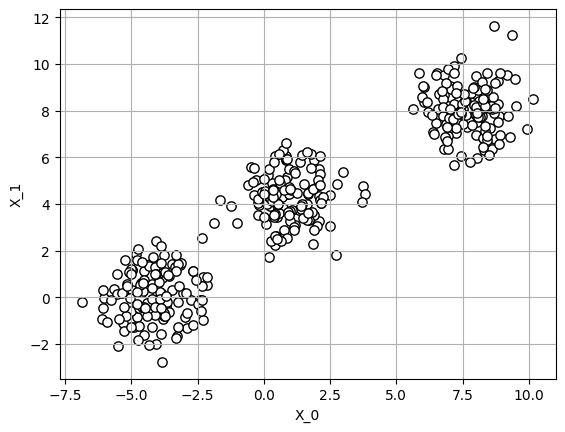

In [123]:
X, y = make_blobs(
    n_samples=400,
    n_features=2,
    centers=3,
    random_state=3
)

plt.scatter(X[:,0], X[:,1], c='white', marker='o', edgecolor='black', s=45)
plt.xlabel('X_0')
plt.ylabel('X_1')
plt.grid()
plt.show()

Apply the model

In [124]:
km = KMeans(
    n_clusters=6,
    init='k-means++', # use k-means++ to initialize the three centroids
    n_init=10, # the entire algorithm will run 10 separate times with 10 different random starting seeds
    max_iter=300, # set a hard limit on how many times the algorithm can move the centroids in a single run
    tol=1e-4, #defines the stopping criterion, if the changes between two iterations is less than 0.0001, the algorithm will stop early
    random_state=1
)

y_km = km.fit_predict(X)

In [125]:
# centroids
km.cluster_centers_

array([[ 8.01068584,  7.35851152],
       [-3.75109517,  0.94765628],
       [ 1.39540515,  5.15875099],
       [-4.54707627, -0.65991857],
       [ 0.64193558,  3.60997303],
       [ 7.42809415,  8.93806246]])

plot the clusters

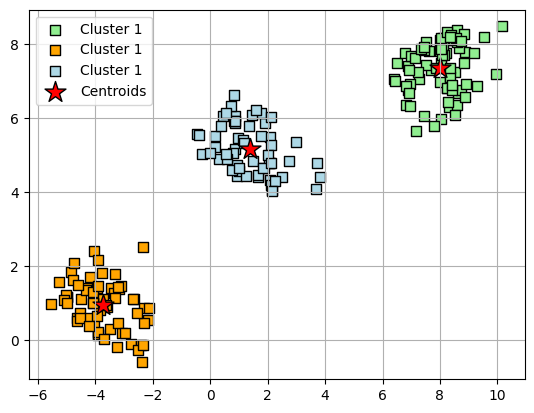

In [126]:
plt.scatter(X[y_km==0, 0],
            X[y_km==0, 1],
            s=50, 
            c='lightgreen',
            marker='s',
            edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km==1, 0],
            X[y_km==1, 1],
            s=50, 
            c='orange',
            marker='s',
            edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km==2, 0],
            X[y_km==2, 1],
            s=50, 
            c='lightblue',
            marker='s',
            edgecolor='black',
            label='Cluster 1')
plt.scatter(km.cluster_centers_[:3,0],
            km.cluster_centers_[:3,1],
            s=250,
            marker='*',
            c='red',
            edgecolor='black',
            label='Centroids')
plt.legend()
plt.grid()

In [127]:
print(f'within-cluster SSE: {km.inertia_:.2f}')

within-cluster SSE: 508.26


### Best K values
- Elbow method

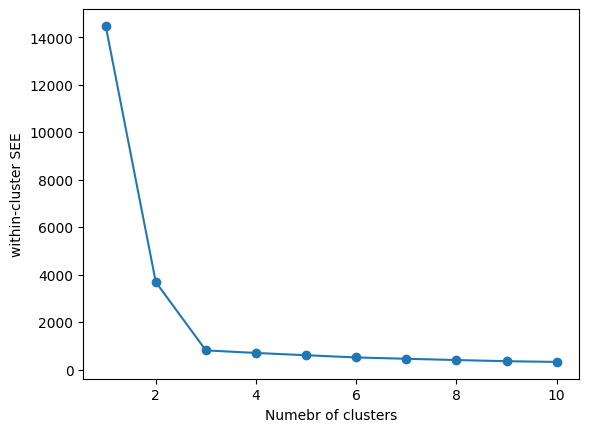

As we can see, the best centroids (clusters) are 3, since the elbow drop slower after 3 clusters


In [128]:
wc_SSE = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=0
    )
    km.fit(X)
    wc_SSE.append(km.inertia_)
plt.plot(range(1,11), wc_SSE, marker='o')
plt.xlabel('Numebr of clusters')
plt.ylabel('within-cluster SEE')
plt.show()
print('As we can see, the best centroids (clusters) are 3, since the elbow drop slower after 3 clusters')

### **Silhoutte Method**

The **Silhouette Method** is a technique used to determine the **optimal number of clusters ($k$)** in a dataset. 

While the "Elbow Method" looks at how much error (Inertia) decreases, the Silhouette Method looks at how well-defined and separated the resulting clusters are. It evaluates both **cohesion** (how close points are to their own cluster) and **separation** (how far they are from other clusters).

---

### 1. The Core Metric: The Silhouette Coefficient
For every single data point $i$, we calculate a score $s(i)$ using the following formula:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

Where:
*   **$a(i)$ (Cohesion):** The average distance between point $i$ and all other points in the **same** cluster. A small $a(i)$ means the cluster is dense and tight.
*   **$b(i)$ (Separation):** The average distance between point $i$ and all points in the **nearest neighboring cluster**. A large $b(i)$ means the clusters are far apart.

### 2. Interpreting the Score
The score for an individual point ranges from **-1 to +1**:
*   **Near +1:** The point is perfectly placed; it is very close to its neighbors and far from other clusters.
*   **Near 0:** The point is on the "borderline" between two clusters (the clusters are overlapping).
*   **Near -1:** The point has likely been assigned to the wrong cluster (it is closer to a different group than its own).

---

### 3. How to use it to find "Optimal $k$"
To find the best number of clusters, you perform the following steps:
1.  Run the clustering algorithm (e.g., K-Means) for a range of $k$ values (e.g., $k=2$ to $k=10$).
2.  For each $k$, calculate the **Mean Silhouette Coefficient** for all points in the dataset.
3.  Plot the **Average Silhouette Score vs. $k$**.
4.  **The Winner:** The value of $k$ that yields the **highest average silhouette score** is considered the optimal number of clusters.

---

### 4. Comparison: Elbow Method vs. Silhouette Method

| Feature | Elbow Method | Silhouette Method |
| :--- | :--- | :--- |
| **Metric Used** | **Inertia (WCSS)** | **Silhouette Coefficient** |
| **What it measures** | How much the error decreases. | How well-separated/distinct clusters are. |
| **Visual Cue** | Look for the "bend" in the curve. | Look for the **highest peak** in the graph. |
| **Complexity** | Very simple and fast. | More computationally expensive (calculates all pair-wise distances). |
| **Clarity** | Can be ambiguous (the "elbow" isn't always clear). | Usually provides a much clearer, unambiguous peak. |

### Summary
If the **Elbow Method** tells you when adding more clusters stops providing significant benefits, the **Silhouette Method** tells you when your clusters are at their most distinct and well-separated state.

#### **silhouette_score: mean silhouette score each k**

For k = 2, the average Silhouette Score is: 0.656644
For k = 3, the average Silhouette Score is: 0.735572
For k = 4, the average Silhouette Score is: 0.598501
For k = 5, the average Silhouette Score is: 0.473739
For k = 6, the average Silhouette Score is: 0.325541
For k = 7, the average Silhouette Score is: 0.333720
For k = 8, the average Silhouette Score is: 0.343079
For k = 9, the average Silhouette Score is: 0.350359
For k = 10, the average Silhouette Score is: 0.354638


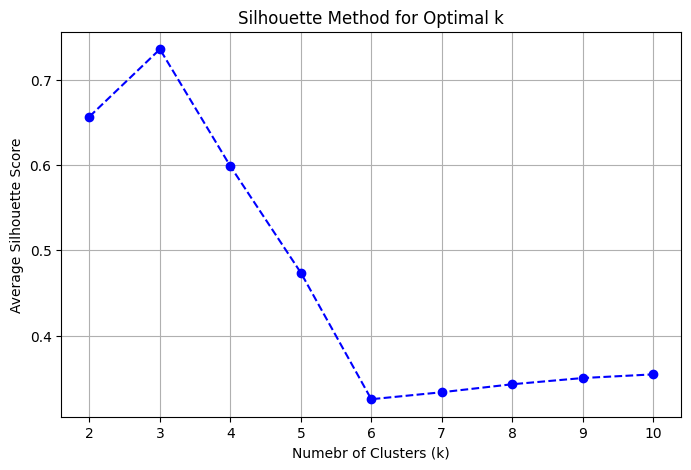

In [129]:
from sklearn.metrics import silhouette_score

silhouette_avg_scores = []
k_range = range(2,11) # we start from 2 because silhouette needs at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k,  init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # calculate the mean silhouette score for k
    score = silhouette_score(X, cluster_labels)
    silhouette_avg_scores.append(score)
    print(f'For k = {k}, the average Silhouette Score is: {score:4f}')

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_avg_scores, marker='o', color='b', linestyle='--')
plt.xlabel('Numebr of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid()
plt.show()

#### **silhouette_samples: silhouette score for each sample**

In [132]:
from sklearn.metrics import silhouette_samples

km = KMeans(n_clusters=3,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)

silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')

print('Few examples of the silhouette values: \n', silhouette_vals[:50])
print('\nMinimum value:', min(silhouette_vals),
      '\nMaximum values:', max(silhouette_vals))

Few examples of the silhouette values: 
 [0.7215202  0.83831232 0.71442755 0.78046356 0.78822073 0.75645494
 0.67214976 0.68002616 0.69048177 0.7124024  0.73465508 0.78909621
 0.69589353 0.77698765 0.42923079 0.71871669 0.70184436 0.73990166
 0.8028051  0.67899555 0.83522181 0.83116947 0.61645361 0.7308917
 0.6224568  0.77934983 0.64595227 0.7584063  0.78912331 0.78758224
 0.66308159 0.67994424 0.72335295 0.73610446 0.72846193 0.81192445
 0.78842891 0.7829639  0.79287835 0.75844363 0.78953365 0.5715837
 0.62457098 0.68443906 0.7573871  0.73762065 0.79144674 0.782365
 0.80430117 0.82922696]

Minimum value: 0.16847325691018333 
Maximum values: 0.8452007934353248


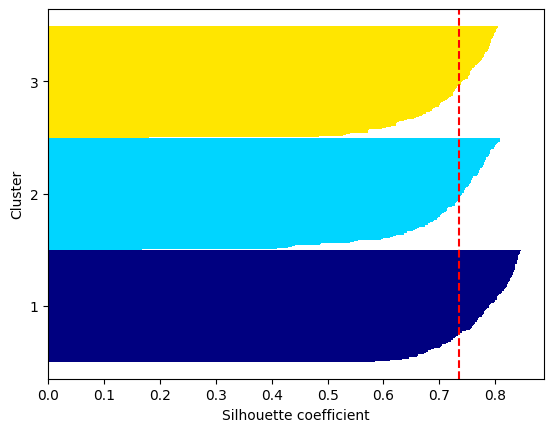

In [133]:
# plot the silhouette values for each point
from matplotlib import cm

cluster_labels = np.unique(y_km)
n_clusters = len(cluster_labels)

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km==c] # grab the silhouette values for each cluster
    c_silhouette_vals.sort()

    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)

    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)
    
    yticks.append((y_ax_lower + y_ax_upper) / 2.0)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color='red', linestyle='--')

plt.yticks(yticks, cluster_labels +1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.show()



---
---

### **Agglomerative Hierarchical Clustering**

**Agglomerative Hierarchical Clustering** is a "bottom-up" clustering method where each data point begins in its own cluster, and pairs of clusters are successively merged based on their proximity until all points are contained in a single cluster.

### 1. The Process (Step-by-Step)
1.  **Initialization:** Treat every individual data point as a single cluster (leaf node).
2.  **Proximity Calculation:** Compute the distance (similarity) between all clusters using a distance metric (e.g., Euclidean distance).
3.  **Merging:** Find the two clusters that are closest to each other and merge them into one new cluster.
4.  **Update:** Recalculate the distances between the newly formed cluster and all remaining clusters.
5.  **Iteration:** Repeat steps 3 and 4 until only one large cluster remains containing all data points.

### 2. Linkage Criteria (How distance is measured)
The method used to determine the distance between *groups* of points is called "linkage." Common types include:
*   **Single Linkage (Nearest Neighbor):** Distance between the two closest members of the clusters. (Can lead to "chaining" effects).
*   **Complete Linkage (Farthest Neighbor):** Distance between the two most distant members of the clusters. (Produces compact, spherical clusters).
*   **Average Linkage (UPGMA):** The average distance between all pairs of points in the two clusters.
*   **Ward’s Method:** Minimizes the increase in total within-cluster variance after merging. This is often the most effective for creating clusters of similar size.

### 3. The Dendrogram
The output of this algorithm is visualized using a **Dendrogram** (a tree-like diagram). 
*   The **y-axis** represents the distance/dissimilarity at which clusters were merged.
*   The **x-axis** represents the individual data points.
*   **Determining Clusters:** To decide how many clusters to use, you "cut" the dendrogram horizontally. The number of vertical lines intersected by the horizontal cut determines the number of clusters ($k$).

### 4. Advantages and Disadvantages
**Advantages:**
*   Does not require pre-specifying the number of clusters (unlike K-Means).
*   The hierarchical structure provides a rich intuitive understanding of data relationships.
*   Can capture any shape of cluster depending on the linkage used.

**Disadvantages:**
*   **Complexity:** Computationally expensive ($O(n^3)$ or $O(n^2 \log n)$), making it difficult to use on very large datasets.
*   **Irreversibility:** Once two clusters are merged, they cannot be unmerged in later steps of the algorithm.
*   **Sensitivity:** Highly sensitive to noise and outliers (especially Single Linkage).

In [134]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

In [135]:
# pull the first 5 samples for simpilicity
df = pd.DataFrame(X[:5, :])

In [136]:
df

,0,1
0,6.492452,7.488167
1,7.747579,8.514398
2,-4.284429,1.424791
3,-5.096727,-0.680588
4,-5.090189,0.224971


In [137]:
labels = ["ID_0", "ID_1", "ID_2", "ID_3", "ID_4"]
row_dist = pd.DataFrame(squareform(pdist(df, metric='euclidean')),
                        columns=labels,
                        index=labels)
row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,1.621263,12.365504,14.178774,13.671561
ID_1,1.621263,0.000000,13.965377,15.796328,15.281456
ID_2,12.365504,13.965377,0.000000,2.256645,1.445274
ID_3,14.178774,15.796328,2.256645,0.000000,0.905582
ID_4,13.671561,15.281456,1.445274,0.905582,0.000000


In [138]:
pdist(df)

array([ 1.62126326, 12.36550423, 14.17877384, 13.67156126, 13.9653769 ,
       15.79632774, 15.28145582,  2.25664502,  1.44527387,  0.90558228])

In [139]:
row_clusters = linkage(pdist(df))
row_clusters

array([[ 3.        ,  4.        ,  0.90558228,  2.        ],
       [ 2.        ,  5.        ,  1.44527387,  3.        ],
       [ 0.        ,  1.        ,  1.62126326,  2.        ],
       [ 6.        ,  7.        , 12.36550423,  5.        ]])

In [140]:
pd.DataFrame(row_clusters,
             columns = ['row label 1', 'row label 2', 'distance', 'no. of itmes in clust.'],
             index = ['cluster %d' % (i+1)
                      for i in range(row_clusters.shape[0])]
)

,row label 1,row label 2,distance,no. of itmes in clust.
cluster 1,3.0,4.0,0.905582,2.0
cluster 2,2.0,5.0,1.445274,3.0
cluster 3,0.0,1.0,1.621263,2.0
cluster 4,6.0,7.0,12.365504,5.0


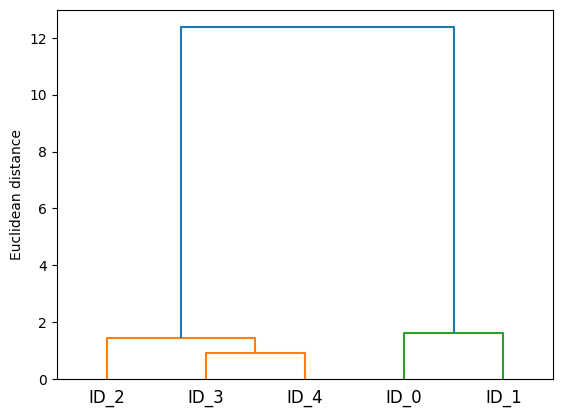

In [141]:
row_dendr = dendrogram(row_clusters,
                       labels=labels,
                       )
plt.ylabel('Euclidean distance');

Scikit-learning

In [142]:
from sklearn.cluster import AgglomerativeClustering

In [143]:
ac = AgglomerativeClustering(
    n_clusters=6,
    linkage='complete'
)
y_ac = ac.fit_predict(X)


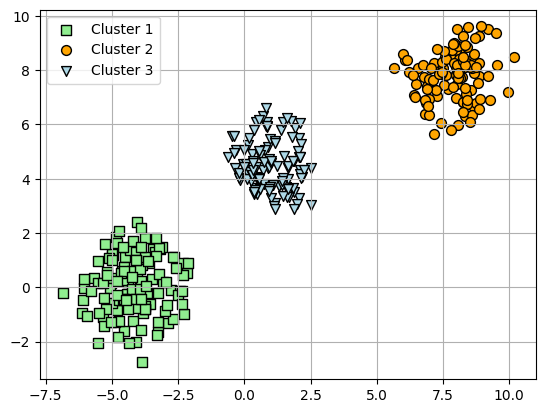

In [144]:
# visualize cluster predictions
plt.scatter(X[y_ac == 0, 0],
            X[y_ac == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_ac == 1, 0],
            X[y_ac == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='Cluster 2')
plt.scatter(X[y_ac == 2, 0],
            X[y_ac == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='Cluster 3')
plt.legend(scatterpoints=1)
plt.grid()

---
---

## **DBSCAN:**

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a non-parametric, density-based clustering algorithm. Unlike K-Means, which assumes clusters are spherical and requires the number of clusters ($k$) to be specified beforehand, DBSCAN identifies clusters based on the density of data points in a given area.

### **Core Concepts**
DBSCAN relies on two key hyperparameters:
1.  **$\epsilon$ (Epsilon):** The maximum distance between two points for one to be considered in the neighborhood of the other.
2.  **MinPts (Minimum Points):** The minimum number of points required to form a dense region (a cluster).

### **Point Classifications**
Based on $\epsilon$ and $MinPts$, every point in the dataset is categorized as:
*   **Core Point:** A point that has at least $MinPts$ within its $\epsilon$-neighborhood.
*   **Border Point:** A point that has fewer than $MinPts$ in its neighborhood but is reachable from a Core Point.
*   **Noise (Outlier):** A point that is neither a Core Point nor a Border Point.

### **How the Algorithm Works**
1.  Pick an arbitrary unvisited point.
2.  If the point has $\ge MinPts$ within distance $\epsilon$, a new cluster is started, and the point is marked as a **Core Point**.
3.  Expand the cluster by recursively adding all density-reachable points (points within $\epsilon$ of the core point).
4.  If a point is reachable but does not meet the $MinPts$ criteria, it is labeled a **Border Point**.
5.  Repeat until all points have been visited. Any points that cannot be assigned to a cluster are labeled as **Noise**.

### **Key Advantages**
*   **No need to specify $k$:** You do not need to know the number of clusters in advance.
*   **Arbitrary Shapes:** It can find clusters of any shape (e.g., elongated, ring-shaped, or intertwined), whereas K-Means only finds spherical clusters.
*   **Robust to Outliers:** It explicitly identifies and labels noise/outliers rather than forcing them into a cluster.

### **Key Disadvantages**
*   **Varying Densities:** It struggles with datasets where clusters have significantly different densities (a single $\epsilon$ cannot capture both dense and sparse clusters).
*   **Sensitivity to Hyperparameters:** Choosing the right $\epsilon$ and $MinPts$ can be difficult; small changes in $\epsilon$ can lead to vastly different clustering results.
*   **High Dimensionality:** In very high-dimensional spaces, the concept of "distance" becomes less meaningful (the Curse of Dimensionality), making density detection difficult.

### **What if 2 points both meet the minPts, and in the $\epsilon$ range**
If two points both meet the **MinPts** requirement and their $\epsilon$-neighborhoods overlap, they are both classified as **Core Points**, and they will belong to the **same cluster**.

Here is exactly what happens:

1.  **Cluster Merging:** In DBSCAN, if a point in Cluster A is within distance $\epsilon$ of a point in Cluster B, the two clusters are automatically merged into one single, larger cluster.
2.  **Density Connectivity:** Because both points meet the $MinPts$ threshold, they act as "anchors" for density. The algorithm treats them as part of a continuous dense region. Any point reachable from either core point becomes part of this unified cluster.
3.  **The Result:** Instead of two separate clusters, you get one larger, irregularly shaped cluster that encompasses the overlapping area and all points connected through these two core points.

**In short: Overlapping core points do not create separate clusters; they act as a bridge that merges those regions into a single cluster.**

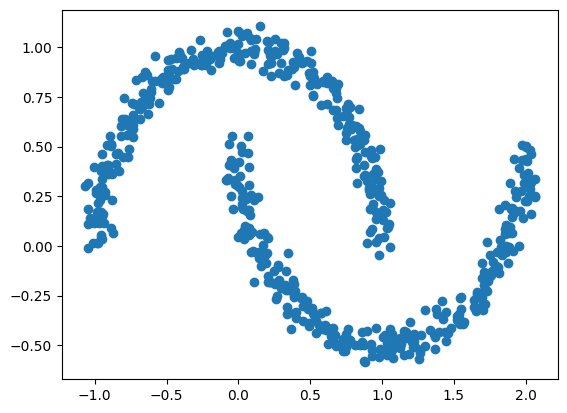

In [149]:
X, y = make_moons(n_samples=600,
                  noise=0.05,
                  random_state=0)
plt.scatter(X[:, 0],
            X[:, 1]);

In [150]:
from sklearn.cluster import DBSCAN

DBSCAN method

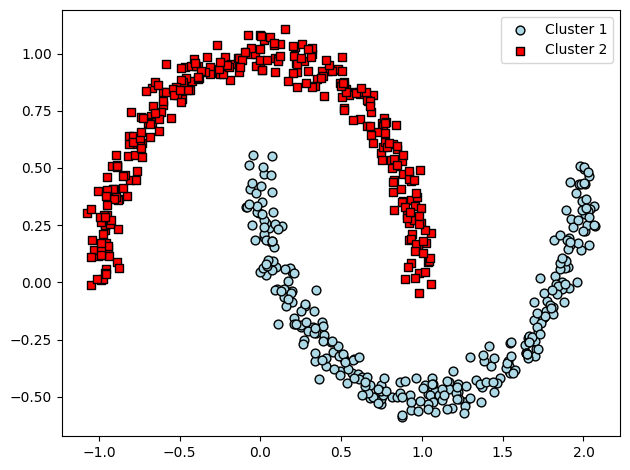

In [154]:
db = DBSCAN(eps=0.2, 
            min_samples=5,
            metric='euclidean')
y_db = db.fit_predict(X)

# plot labels
plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1],
            c='lightblue', marker='o', s=40,
            edgecolor='black', 
            label='Cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1],
            c='red', marker='s', s=40,
            edgecolor='black', 
            label='Cluster 2')
plt.legend()
plt.tight_layout()
plt.show()

KMeans Method

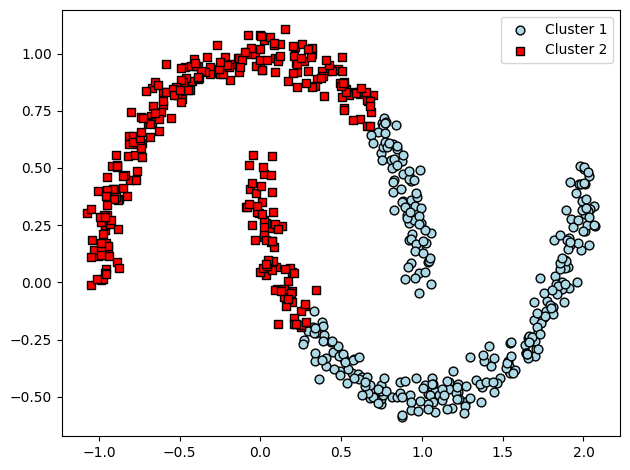

In [156]:
db = KMeans(n_clusters=2,
            )
y_db = db.fit_predict(X)

# plot labels
plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1],
            c='lightblue', marker='o', s=40,
            edgecolor='black', 
            label='Cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1],
            c='red', marker='s', s=40,
            edgecolor='black', 
            label='Cluster 2')
plt.legend()
plt.tight_layout()
plt.show()

Hierarchical Cluster

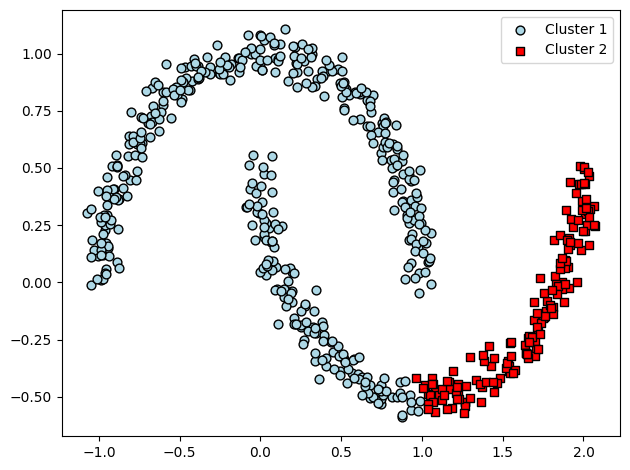

In [153]:
db = AgglomerativeClustering(
    n_clusters=2
)
y_db = db.fit_predict(X)

# plot labels
plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1],
            c='lightblue', marker='o', s=40,
            edgecolor='black', 
            label='Cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1],
            c='red', marker='s', s=40,
            edgecolor='black', 
            label='Cluster 2')
plt.legend()
plt.tight_layout()
plt.show()